In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()

# X = iris['data']
# y = iris['target']

# X.shape

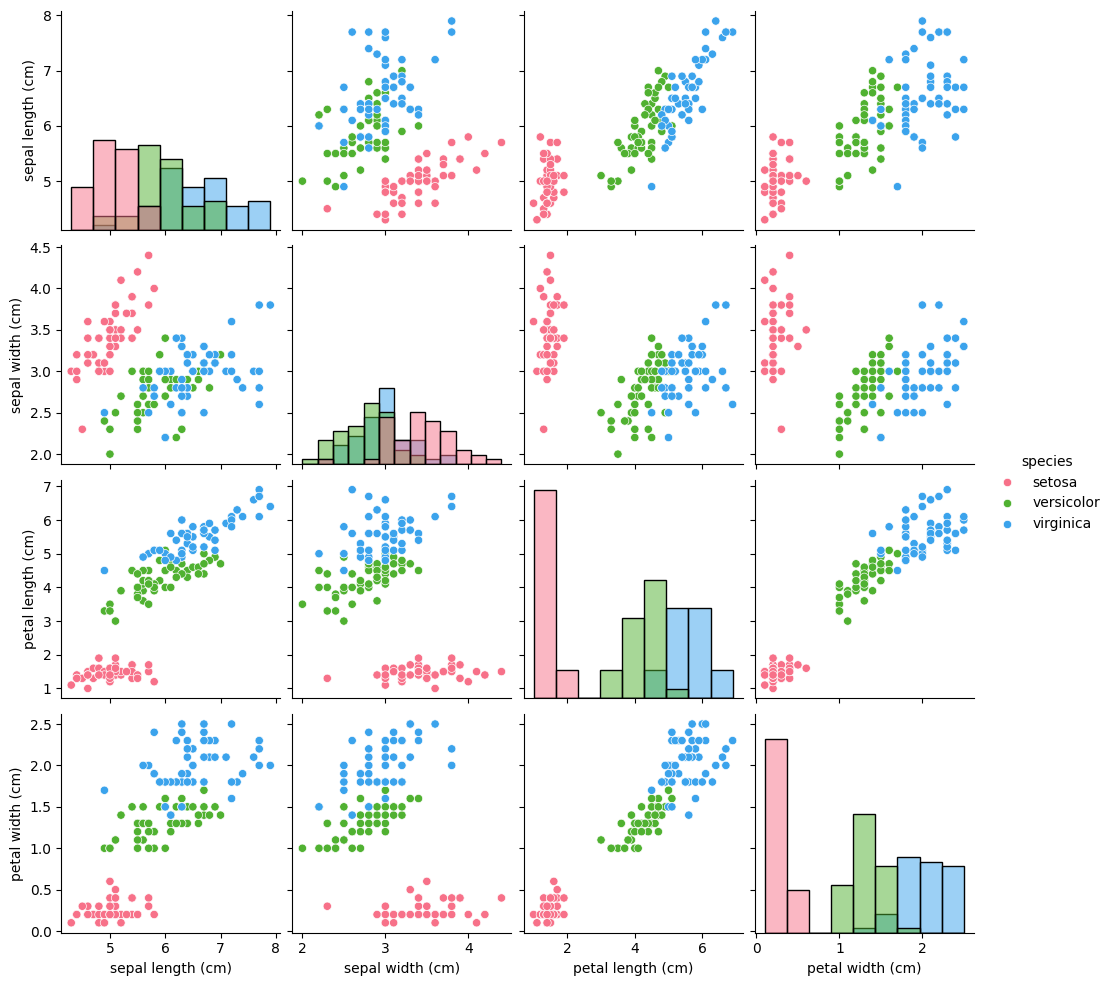

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

# Convert target numbers to species names
df["species"] = df["species"].map({0: "setosa", 1: "versicolor", 2: "virginica"})

# Seaborn pairplot
sns.pairplot(df, hue="species", diag_kind="hist", palette="husl")
plt.show()

Standardize the DataSet :


> Standardization transforms data to have:
* ✅ Mean = 0
* ✅ Standard deviation = 1

This helps models perform better and faster by making features comparable by preventing features with large values from dominating the learning process.





In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Instead of Standard Scalar we can use the below code for standardizing the dataset

In [ ]:
def Standardize_data(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)


X_std = Standardize_data(X)

The covariance matrix of standardized data can be calculated as follows.


In [ ]:
def covariance(x):
    return (x.T @ x) / (x.shape[0] - 1)


cov_mat = covariance(X_scaled)  # np.cov(X_scaled.T)

Alternate approach for the covaraince matrix

In [ ]:
import numpy as np

cov_mat_using_np = np.cov(X_scaled.T)

Find the eigenvectors and eigenvalues of the covariance matrix

> We adjust the signs of the eigenvectors to ensure that the largest value in each eigenvector is positive. This is done for consistency and interpretability, as eigenvectors can be scaled or flipped arbitrarily without changing their direction. By aligning the eigenvectors this way, we make the results more interpretable and reproducible across different computations or datasets.





In [ ]:
from numpy.linalg import eig

# Eigendecomposition of covariance matrix
eig_vals, eig_vecs = eig(cov_mat)
print("Eigenvectors \n", eig_vecs)

# Adjusting the eigenvectors (loadings) that are largest in absolute value to be positive
max_abs_idx = np.argmax(np.abs(eig_vecs), axis=0)
vec_with_max_val = eig_vecs[max_abs_idx, range(eig_vecs.shape[0])]
print(vec_with_max_val)
signs = np.sign(vec_with_max_val)
eig_vecs = eig_vecs * signs[np.newaxis, :]

eig_vecs = eig_vecs.T  # Transposing The Matrix

print("Eigenvalues \n", eig_vals)
print("Eigenvectors \n", eig_vecs)

Eigenvectors 
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]
[ 0.5804131  -0.92329566 -0.71956635 -0.80144925]
Eigenvalues 
 [2.93808505 0.9201649  0.14774182 0.02085386]
Eigenvectors 
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


Rearrange the eigenvectors and eigenvalues

The eigenvalues represent the amount of variance explained by each principal component. Larger eigenvalues correspond to components that explain more variance. So, the first step is to sort the eigenvalues in descending order.

Eigenvalue order: Sort the eigenvalues from largest to smallest.
Eigenvector order: Reorder the eigenvectors to match the sorted eigenvalues. This ensures that the corresponding eigenvectors are aligned with the decreasing variance.


In [ ]:
# We first make a list of (eigenvalue, eigenvector) tuples
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[i, :]) for i in range(len(eig_vals))]

# Then, we sort the tuples from the highest to the lowest based on eigenvalues magnitude
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# For further usage
eig_vals_sorted = np.array([x[0] for x in eig_pairs])
eig_vecs_sorted = np.array([x[1] for x in eig_pairs])

print(eig_pairs)

[(2.9380850501999918, array([ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654])), (0.920164904162487, array([0.37741762, 0.92329566, 0.02449161, 0.06694199])), (0.14774182104494785, array([ 0.71956635, -0.24438178, -0.14212637, -0.63427274])), (0.020853862176462023, array([-0.26128628,  0.12350962,  0.80144925, -0.52359713]))]


Choose principal components

* Eigenvalues represent the variance explained by each principal component in PCA.
* To retain 90% of the total variance, sum the eigenvalues in descending order and select the smallest k such that the cumulative variance is 90%.
* This method allows for dimensionality reduction while preserving most of the data's information.








In [ ]:
# Select top k eigenvectors
k = 2
W = eig_vecs_sorted[:k, :]  # Projection matrix

print(W.shape)
W

(2, 4)


array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199]])

Explained variance: [72.96 22.85  3.67  0.52]
Cumulative explained variance: [ 72.96  95.81  99.48 100.  ]


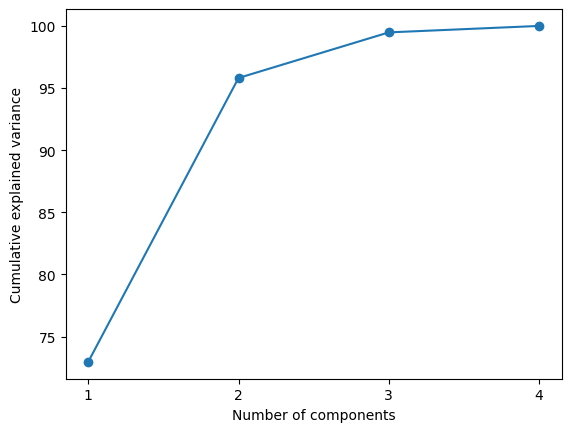

In [ ]:
n_features = 4

eig_vals_total = sum(eig_vals)
explained_variance = [(i / eig_vals_total) * 100 for i in eig_vals_sorted]
explained_variance = np.round(explained_variance, 2)
cum_explained_variance = np.cumsum(explained_variance)

print("Explained variance: {}".format(explained_variance))
print("Cumulative explained variance: {}".format(cum_explained_variance))

plt.plot(np.arange(1, n_features + 1), cum_explained_variance, "-o")
plt.xticks(np.arange(1, n_features + 1))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.show()

Project the data

In [ ]:
X_proj = X_scaled.dot(W.T)

print(X_proj.shape)

(150, 2)


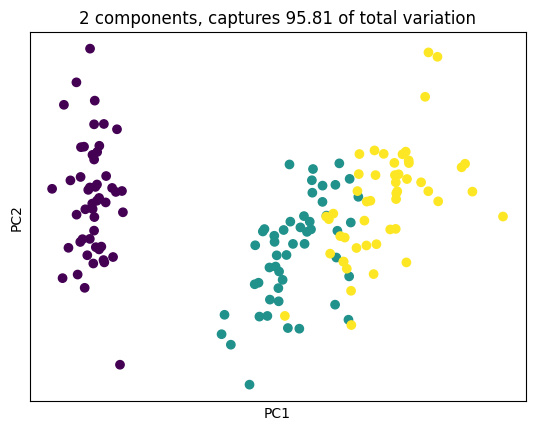

In [ ]:
plt.scatter(X_proj[:, 0], X_proj[:, 1], c=iris["target"])
plt.xlabel("PC1")
plt.xticks([])
plt.ylabel("PC2")
plt.yticks([])
plt.title(
    "2 components, captures {} of total variation".format(cum_explained_variance[1])
)
plt.show()

# PCA with Scikit-Learn

Components:
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]
Explained variance ratio:
 [0.72962445 0.22850762]
Cumulative explained variance:
 [0.72962445 0.95813207]
Transformed data shape: (150, 2)


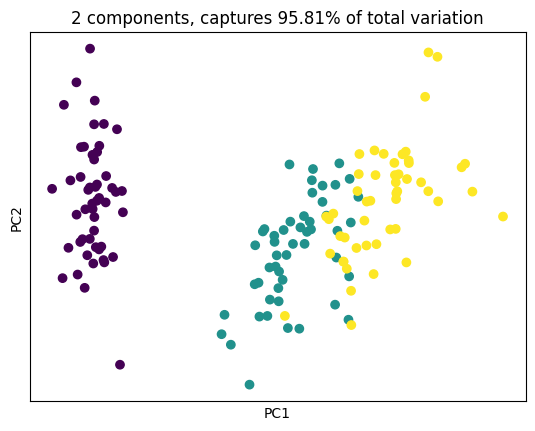

In [ ]:
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(0.95).fit(X_scaled)

print("Components:\n", pca.components_)
print("Explained variance ratio:\n", pca.explained_variance_ratio_)

cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative explained variance:\n", cum_explained_variance)

X_pca = pca.transform(X_std)  # Apply dimensionality reduction to X.
print("Transformed data shape:", X_pca.shape)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=iris["target"])
plt.xlabel("PC1")
plt.xticks([])
plt.ylabel("PC2")
plt.yticks([])
plt.title(
    "2 components, captures {}% of total variation".format(
        cum_explained_variance[1].round(4) * 100
    )
)
plt.show()